In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import cm

In [20]:
df = pd.read_csv("C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv")

In [21]:
# Converting to boolean 
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Rural": 1, "Urban": 0})

In [22]:
# Combine features
X = df.drop('stroke', axis=1)
y = df['stroke']

In [23]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [24]:
# Encode categorical features
ohe = OneHotEncoder(drop= None, sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])

In [25]:
# Scale numerical features
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

In [26]:
X_bin = X[bin_cols].to_numpy()

In [27]:
# Concatenate all features
X_all = np.concatenate([X_bin, X_num, X_cat], axis=1)
y = np.array(y).astype(int)

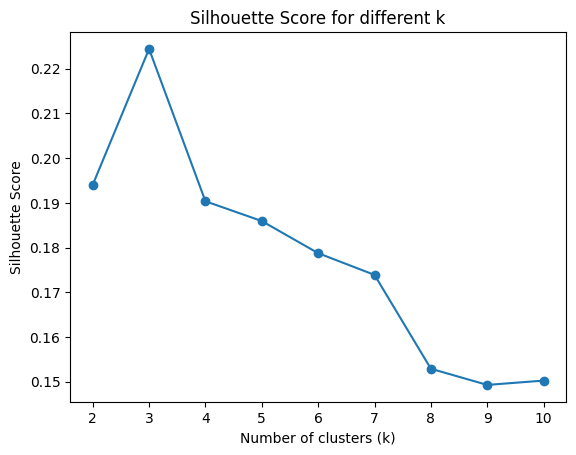

In [49]:
sil_scores = []
k_values = range(2, 11) 

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_all)
    score = silhouette_score(X_all, labels)
    sil_scores.append(score)

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for different k")
plt.show()

In [31]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

In [32]:
# Get full feature names
feature_names = bin_cols + num_cols + list(ohe.get_feature_names_out(cat_cols))

In [33]:
# Extract PCA loadings (contribution of each feature to PC1, PC2)
loadings = pca.components_.T
pca_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=feature_names)

In [34]:
# Add absolute values of contributions for sorting
pca_df['abs_PC1'] = pca_df['PC1'].abs()
pca_df['abs_PC2'] = pca_df['PC2'].abs()

In [35]:
# Sort features by importance in PC1
# We used ChatGPT to build a well-designed and organized table to present the features in the best possible way.
top_pc1 = pca_df.sort_values(by='abs_PC1', ascending=False).head(10)

# Table
styled_top_pc1 = top_pc1.style \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ]) \
    .set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial',
        'font-size': '13px'
    }) \
    .set_caption("Top 10 Features Contributing to PC1") \
    .format("{:.2f}")

display(styled_top_pc1)

,PC1,PC2,abs_PC1,abs_PC2
age,0.63,-0.18,0.63,0.18
bmi,0.54,-0.31,0.54,0.31
avg_glucose_level,0.40,0.90,0.40,0.90
ever_married,0.24,-0.10,0.24,0.10
work_type_children,-0.18,0.11,0.18,0.11
smoking_status_Unknown,-0.17,0.09,0.17,0.09
work_type_Private,0.08,-0.09,0.08,0.09
smoking_status_never smoked,0.07,-0.05,0.07,0.05
work_type_Self-employed,0.07,-0.01,0.07,0.01
smoking_status_formerly smoked,0.07,-0.01,0.07,0.01


In [36]:
# Sort features by importance in PC2
top_pc2 = pca_df.sort_values(by='abs_PC2', ascending=False).head(10)

# Table
styled_top_pc2 = top_pc2.style \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ]) \
    .set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial',
        'font-size': '13px'
    }) \
    .set_caption("Top 10 Features Contributing to PC2") \
    .format("{:.2f}")

display(styled_top_pc2)

,PC1,PC2,abs_PC1,abs_PC2
avg_glucose_level,0.40,0.90,0.40,0.90
bmi,0.54,-0.31,0.54,0.31
age,0.63,-0.18,0.63,0.18
work_type_children,-0.18,0.11,0.18,0.11
ever_married,0.24,-0.10,0.24,0.10
gender_Female,0.01,-0.09,0.01,0.09
gender_Male,-0.01,0.09,0.01,0.09
work_type_Private,0.08,-0.09,0.08,0.09
smoking_status_Unknown,-0.17,0.09,0.17,0.09
smoking_status_never smoked,0.07,-0.05,0.07,0.05


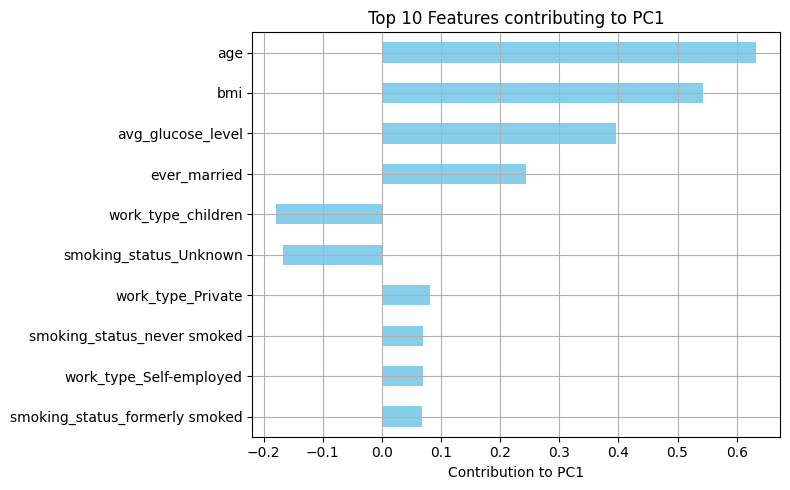

In [37]:
# Graph of top 10 Features contributing to PC1
pca_df.sort_values(by='abs_PC1', ascending=False).head(10)['PC1'].plot(
    kind='barh', title='Top 10 Features contributing to PC1', figsize=(8,5), color='skyblue')
plt.xlabel("Contribution to PC1")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

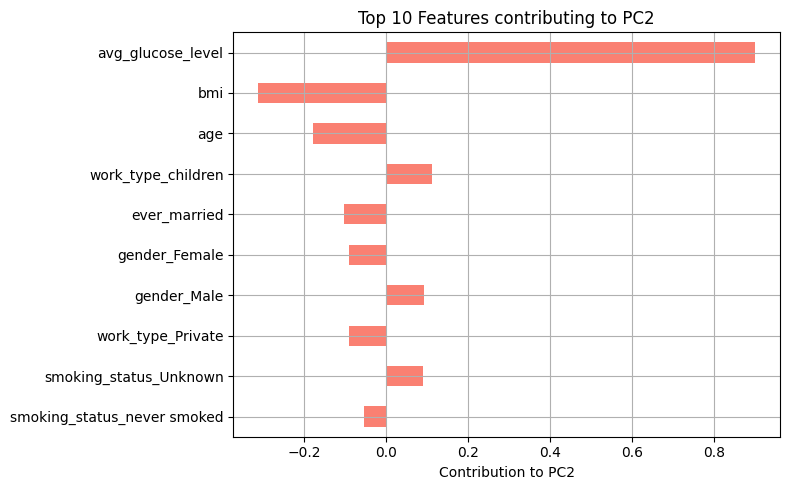

In [38]:
# Graph of top 10 Features contributing to PC2
pca_df.sort_values(by='abs_PC2', ascending=False).head(10)['PC2'].plot(
    kind='barh', title='Top 10 Features contributing to PC2', figsize=(8,5), color='salmon')
plt.xlabel("Contribution to PC2")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

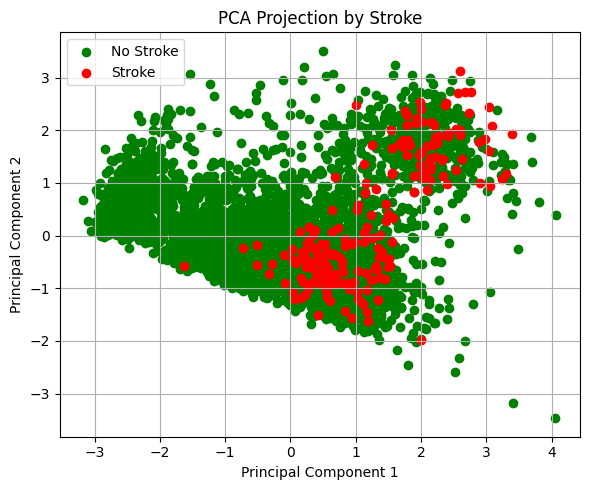

In [39]:
# Plot for the data after PCA
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='green', label='No Stroke')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='red', label='Stroke')
plt.title("PCA Projection by Stroke")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

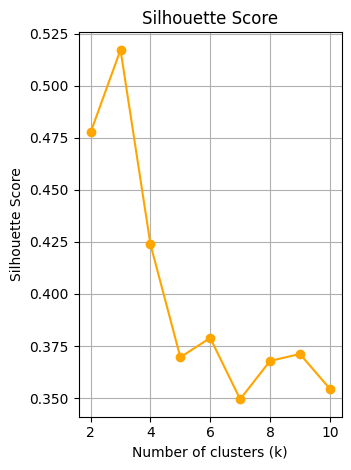

In [47]:
sil_scores = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o', color='orange')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
# Apply KMeans clustering (on 2D PCA space)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

C:\Users\maman\AppData\Local\Temp\ipykernel_21700\2542121219.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set1', len(np.unique(clusters)))


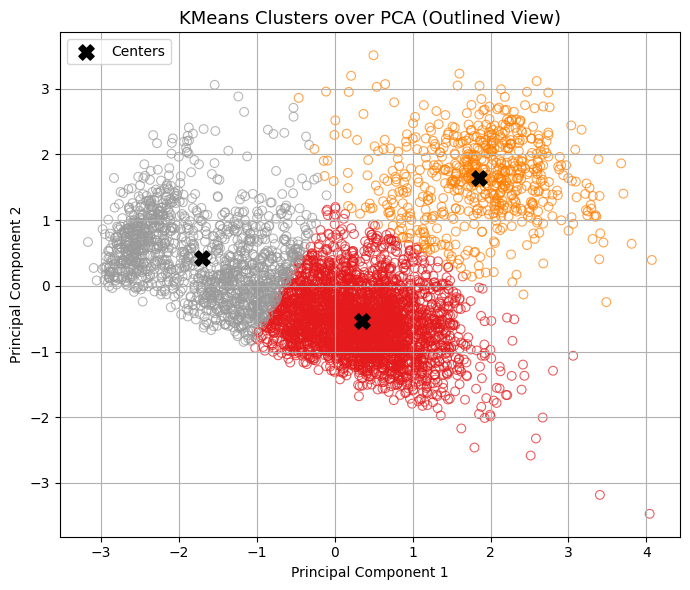

In [51]:
# Plot for the data after KMEANS
# We used ChatGPT to build a well-designed and organized Graph
colors = cm.get_cmap('Set1', len(np.unique(clusters)))
plt.figure(figsize=(7, 6))

for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    color = colors(cluster_id)

    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                facecolors='none',
                edgecolors=[color],
                alpha=0.7,
                linewidth=0.8,
                s=40)

# Centers of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=120, c='black', marker='X', label='Centers')

plt.title("KMeans Clusters over PCA (Outlined View)", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\maman\AppData\Local\Temp\ipykernel_21700\862638874.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(np.unique(clusters)))


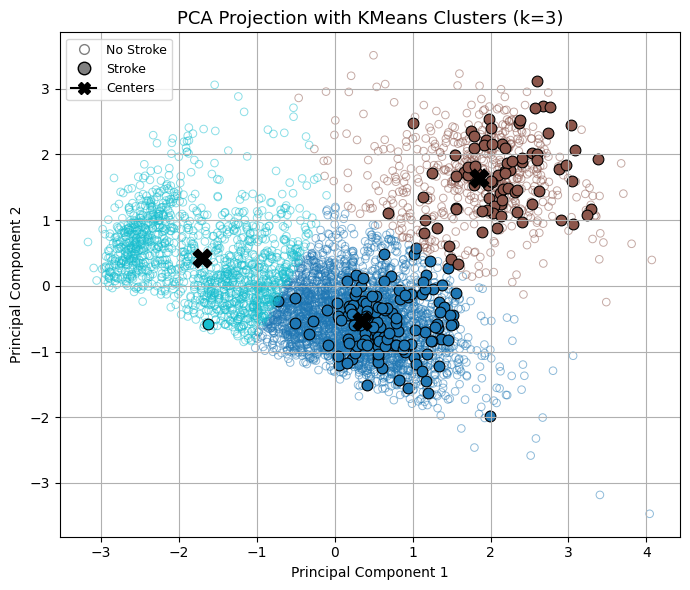

In [53]:
# We used ChatGPT to build a well-designed and organized Graph
colors = cm.get_cmap('tab10', len(np.unique(clusters)))

plt.figure(figsize=(7, 6))

# Drawing the points by cluster and stroke status
for cluster_id in np.unique(clusters):
    cluster_color = colors(cluster_id)
    mask = clusters == cluster_id

    # Not sick - outline only
    plt.scatter(X_pca[mask & (y == 0), 0],
                X_pca[mask & (y == 0), 1],
                facecolors='none',
                edgecolors=[cluster_color],
                alpha=0.5, linewidth=0.7, marker='o', s=30)

    # Stroke patients - full circle with black frame
    plt.scatter(X_pca[mask & (y == 1), 0],
                X_pca[mask & (y == 1), 1],
                color=cluster_color,
                edgecolors='black',
                linewidth=0.8,
                marker='o', s=60, label=f'Cluster {cluster_id}')

# Centers of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=180, c='black', marker='X', label='Centers')

plt.title("PCA Projection with KMeans Clusters (k=3)", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No Stroke',
           markerfacecolor='none', markeredgecolor='gray', markersize=7, linewidth=1),
    Line2D([0], [0], marker='o', color='w', label='Stroke',
           markerfacecolor='gray', markeredgecolor='black', markersize=9),
    Line2D([0], [0], marker='X', color='black', label='Centers', markersize=9)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=9, frameon=True)

plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
# Create summary table: count of samples and strokes per cluster
# We used ChatGPT to build and organized Data
df_analysis = pd.DataFrame({
    'Cluster': clusters,
    'Stroke': y
})
cluster_counts = df_analysis.groupby('Cluster').size().rename('Number of samples')
stroke_counts = df_analysis[df_analysis['Stroke'] == 1].groupby('Cluster').size().rename('Stroke')

# Combine into one DataFrame and calculate stroke percentages
cluster_summary = pd.concat([cluster_counts, stroke_counts], axis=1).fillna(0)
cluster_summary['Stroke'] = cluster_summary['Stroke'].astype(int)
cluster_summary['% Stroke in Cluster'] = (cluster_summary['Stroke'] / cluster_summary['Number of samples'] * 100).round(2)
cluster_summary['% Total Strokes'] = (cluster_summary['Stroke'] / cluster_summary['Stroke'].sum() * 100).round(2)

# Map cluster IDs to actual colors used in the plots
cluster_colors = {
    0: 'Brown',   
    1: 'Blue',       
    2: 'Turquoise'
}

cluster_summary.index = cluster_summary.index.map(cluster_colors)
cluster_summary = cluster_summary.reset_index().rename(columns={'index': 'Cluster Color'})

cluster_summary

,Cluster,Number of samples,Stroke,% Stroke in Cluster,% Total Strokes
0,Brown,2967,128,4.31,61.24
1,Blue,634,80,12.62,38.28
2,Turquoise,1308,1,0.08,0.48


In [57]:
from scipy.stats import ttest_ind
# Create full dataframe for analysis: features + cluster + stroke label
df_features = pd.DataFrame(X_all, columns=feature_names)
df_features['Cluster'] = clusters
df_features['Stroke'] = y

# Store for later use
df_full = df_features.copy()

# Dictionary to store per-cluster feature differences
cluster_feature_differences = {}

# Analyze each cluster separately
for cluster_id in sorted(df_full['Cluster'].unique()):
    cluster_data = df_full[df_full['Cluster'] == cluster_id]  # Get only rows from current cluster
    stroke_group = cluster_data[cluster_data['Stroke'] == 1]  # Patients with stroke
    no_stroke_group = cluster_data[cluster_data['Stroke'] == 0]  # Patients without stroke

    feature_stats = []

    for feature in feature_names:
        # Only analyze features that vary in both groups (required for t-test)
        if stroke_group[feature].nunique() > 1 and no_stroke_group[feature].nunique() > 1:
            t_stat, p_val = ttest_ind(stroke_group[feature], no_stroke_group[feature], equal_var=False)  # Welch’s t-test
            mean_diff = stroke_group[feature].mean() - no_stroke_group[feature].mean()  # Δ mean
            feature_stats.append({
                'Feature': feature,
                'Δ Mean': round(mean_diff, 3),
                'p-value': round(p_val, 4)
            })

    # Keep top 5 features with largest absolute difference in means
    sorted_features = sorted(feature_stats, key=lambda x: abs(x['Δ Mean']), reverse=True)[:5]
    cluster_feature_differences[cluster_id] = sorted_features


In [45]:
# ANSI codes for colored output in terminal
ansi_colors = {
    'Blue': '\033[94m',
    'Green': '\033[92m',
    'Brown': '\033[33m',
    'Gray': '\033[90m',
    'Turquoise': '\033[96m'
}
bold = '\033[1m'
underline = '\033[4m'
reset = '\033[0m'

# Iterate over all clusters and print their feature summary
for cluster_id, feature_list in cluster_feature_differences.items():
    color = cluster_colors[cluster_id]
    color_code = ansi_colors.get(color, '')

    # Title block for the cluster summary
    print(f"\n{'=' * 30}")
    print(f"{color_code}{bold} Cluster color Summary {color}{reset}")
    print(f"{'=' * 30}\n")

    # Sort features by absolute difference in mean
    sorted_features = sorted(feature_list, key=lambda x: abs(x['Δ Mean']), reverse=True)
   
    # Split into significant and not-significant lists
    significant = []
    not_significant = []

    for item in sorted_features:
        feat = item['Feature']
        delta = item['Δ Mean']
        p = item['p-value']

        if p < 0.05:
            significant.append((feat, delta, p))
        else:
            not_significant.append((feat, delta, p))

    # Print significant features with formatting
    print(f"{underline}Features with a possible connection to stroke:{reset}\n")

    if significant:
        for feat, delta, p in significant:
            print(f"• {feat:<30} | Δ Mean: {delta:>6}, p = {p:<7}")
    else:
        print("— There are not enough stroke patients in this cluster to perform statistical analysis.")

    # Print non-significant features for completeness
    print(f"\n{underline}Other features in the cluster (not necessarily related to stroke):{reset}")
    for feat, delta, p in not_significant:
        print(f"•  {feat:<30} | Δ Mean: {delta:>6}, p = {p:<7}")



 Cluster color Summary Blue

Features with a possible connection to stroke:

— There are not enough stroke patients in this cluster to perform statistical analysis.

Other features in the cluster (not necessarily related to stroke):
•  work_type_Private              | Δ Mean: -0.418, p = 0.3361 
•  avg_glucose_level              | Δ Mean: -0.383, p = 0.1763 
•  smoking_status_Unknown         | Δ Mean:  0.341, p = 0.4144 
•  work_type_children             | Δ Mean:  0.279, p = 0.4902 
•  work_type_Self-employed        | Δ Mean:  0.266, p = 0.5088 

 Cluster color Summary Green

Features with a possible connection to stroke:

• age                            | Δ Mean:  0.434, p = 0.0    
• heart_disease                  | Δ Mean:  0.162, p = 0.0032 
• hypertension                   | Δ Mean:  0.123, p = 0.0352 

Other features in the cluster (not necessarily related to stroke):
•  avg_glucose_level              | Δ Mean:  0.078, p = 0.2879 
•  work_type_Private              | Δ Mean:  0